In [1]:

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.decomposition import TruncatedSVD
from collections import defaultdict
import math
import random


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "ml-100k" 

In [5]:
import os
import pandas as pd

DATA_DIR = "ml-100k"
ratings_file = os.path.join(DATA_DIR, "u.data")

# Load ratings
ratings = pd.read_csv(
    ratings_file,
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

print(ratings.head())


   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


In [6]:
import os
import pandas as pd

def load_movielens_100k(data_dir="ml-100k"):
    # Ratings data
    ratings = pd.read_csv(
        os.path.join(data_dir, "u.data"),
        sep="\t",
        names=["user_id", "movie_id", "rating", "timestamp"]
    )

    # Movies data
    movies = pd.read_csv(
        os.path.join(data_dir, "u.item"),
        sep="|",
        header=None,
        encoding="latin-1",
        usecols=[0, 1],
        names=["movie_id", "title"]
    )

    # Users data
    users = pd.read_csv(
        os.path.join(data_dir, "u.user"),
        sep="|",
        header=None,
        names=["user_id", "age", "gender", "occupation", "zip_code"]
    )

    return ratings, movies, users


# --- Load all datasets in one go ---
ratings, movies, users = load_movielens_100k()

print("Ratings:\n", ratings.head(), "\n")
print("Movies:\n", movies.head(), "\n")
print("Users:\n", users.head())


Ratings:
    user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596 

Movies:
    movie_id              title
0         1   Toy Story (1995)
1         2   GoldenEye (1995)
2         3  Four Rooms (1995)
3         4  Get Shorty (1995)
4         5     Copycat (1995) 

Users:
    user_id  age gender  occupation zip_code
0        1   24      M  technician    85711
1        2   53      F       other    94043
2        3   23      M      writer    32067
3        4   24      M  technician    43537
4        5   33      F       other    15213


In [7]:
# Create User-Item Matrix
user_item_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

print("User-Item Matrix Shape:", user_item_matrix.shape)
print(user_item_matrix.head())


User-Item Matrix Shape: (943, 1682)
movie_id  1     2     3     4     5     6     7     8     9     10    ...  \
user_id                                                               ...   
1          5.0   3.0   4.0   3.0   3.0   5.0   4.0   1.0   5.0   3.0  ...   
2          4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   2.0  ...   
3          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
4          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
5          4.0   3.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   

movie_id  1673  1674  1675  1676  1677  1678  1679  1680  1681  1682  
user_id                                                               
1          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
2          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
3          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
4          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN 

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

# Fill NaN with 0 (unrated movies treated as 0)
user_item_filled = user_item_matrix.fillna(0)

# Compute cosine similarity between users
user_similarity = cosine_similarity(user_item_filled)

# Convert to DataFrame for easy handling
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

print("User Similarity Matrix Shape:", user_similarity_df.shape)
print(user_similarity_df.head())


User Similarity Matrix Shape: (943, 943)
user_id       1         2         3         4         5         6         7    \
user_id                                                                         
1        1.000000  0.166931  0.047460  0.064358  0.378475  0.430239  0.440367   
2        0.166931  1.000000  0.110591  0.178121  0.072979  0.245843  0.107328   
3        0.047460  0.110591  1.000000  0.344151  0.021245  0.072415  0.066137   
4        0.064358  0.178121  0.344151  1.000000  0.031804  0.068044  0.091230   
5        0.378475  0.072979  0.021245  0.031804  1.000000  0.237286  0.373600   

user_id       8         9         10   ...       934       935       936  \
user_id                                ...                                 
1        0.319072  0.078138  0.376544  ...  0.369527  0.119482  0.274876   
2        0.103344  0.161048  0.159862  ...  0.156986  0.307942  0.358789   
3        0.083060  0.061040  0.065151  ...  0.031875  0.042753  0.163829   
4        0.

In [11]:
def recommend_movies(user_id, user_item_matrix, user_similarity_df, movies, top_n=5):
    # Get similarity scores for the given user
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:]  # exclude self
    
    # Get top similar users (e.g., top 10)
    top_users = similar_users.head(10).index
    
    # Movies this user has already rated
    user_rated_movies = user_item_matrix.loc[user_id].dropna().index
    
    # Candidate movies = average ratings of top similar users, excluding already seen
    candidate_movies = user_item_matrix.loc[top_users].mean().drop(user_rated_movies, errors="ignore")
    
    # Sort candidate movies by predicted score
    recommended_movies = candidate_movies.sort_values(ascending=False).head(top_n)
    
    # Reset index to turn movie_id from index → column
    recommended_movies = recommended_movies.reset_index()
    recommended_movies.columns = ["movie_id", "predicted_rating"]
    
    # Merge with movie titles
    recommended_movies = recommended_movies.merge(movies, on="movie_id")
    
    return recommended_movies[["movie_id", "title", "predicted_rating"]]


In [12]:
recommendations = recommend_movies(
    user_id=1,
    user_item_matrix=user_item_matrix,
    user_similarity_df=user_similarity_df,
    movies=movies,
    top_n=5
)

print("Recommended Movies for User 1:\n", recommendations)


Recommended Movies for User 1:
    movie_id                                      title  predicted_rating
0      1168                       Little Buddha (1993)               5.0
1       313                             Titanic (1997)               5.0
2      1009                     Stealing Beauty (1996)               5.0
3      1019  Die xue shuang xiong (Killer, The) (1989)               5.0
4      1007                 Waiting for Guffman (1996)               5.0


In [16]:
def recommend_movies_weighted(user_id, user_item_matrix, user_similarity_df, movies, top_n=5, k_neighbors=10):
    # Similarity scores for the given user
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:]
    
    # Pick top k similar users
    top_users = similar_users.head(k_neighbors)
    
    # Get ratings from top similar users
    top_user_ratings = user_item_matrix.loc[top_users.index]
    
    # Weighted ratings: multiply by similarity score
    weighted_ratings = top_user_ratings.T.dot(top_users) / top_users.sum()
    
    # Drop movies the user already rated
    user_rated_movies = user_item_matrix.loc[user_id].dropna().index
    weighted_ratings = weighted_ratings.drop(user_rated_movies, errors="ignore")
    
    # Drop NaN predictions (movies not rated by any similar user)
    weighted_ratings = weighted_ratings.dropna()
    
    # Top N recommendations
    recommended_movies = weighted_ratings.sort_values(ascending=False).head(top_n).reset_index()
    recommended_movies.columns = ["movie_id", "predicted_rating"]
    
    # Add movie titles
    recommended_movies = recommended_movies.merge(movies, on="movie_id")
    
    return recommended_movies[["movie_id", "title", "predicted_rating"]]


In [17]:
recommendations_w = recommend_movies_weighted(
    user_id=1,
    user_item_matrix=user_item_matrix,
    user_similarity_df=user_similarity_df,
    movies=movies,
    top_n=5
)

print("Weighted Recommendations for User 1:\n", recommendations_w)


Weighted Recommendations for User 1:
    movie_id                              title  predicted_rating
0       655                 Stand by Me (1986)          3.696039
1       423  E.T. the Extra-Terrestrial (1982)          3.691327
2       568                       Speed (1994)          3.402757
3       405         Mission: Impossible (1996)          3.196618


In [22]:
import os
import pandas as pd

DATA_DIR = "ml-100k"

train = pd.read_csv(
    os.path.join(DATA_DIR, "u1.base"),
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

test = pd.read_csv(
    os.path.join(DATA_DIR, "u1.test"),
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (80000, 4)
Test shape: (20000, 4)


In [23]:
# Pivot train data
train_matrix = train.pivot_table(index="user_id", columns="movie_id", values="rating")


In [24]:
from sklearn.metrics.pairwise import cosine_similarity

train_matrix_filled = train_matrix.fillna(0)
user_sim_train = cosine_similarity(train_matrix_filled)
user_sim_train_df = pd.DataFrame(user_sim_train, index=train_matrix.index, columns=train_matrix.index)


In [25]:
def precision_at_k(user_id, train_matrix, test_df, user_sim_df, k=5, n_neighbors=10):
    # Get top-k recommendations for this user
    similar_users = user_sim_df[user_id].sort_values(ascending=False)[1:].head(n_neighbors)
    top_users = similar_users.index
    user_rated = train_matrix.loc[user_id].dropna().index
    
    # Weighted ratings
    weighted_ratings = train_matrix.loc[top_users].T.dot(similar_users) / similar_users.sum()
    weighted_ratings = weighted_ratings.drop(user_rated, errors="ignore").dropna()
    
    # Top-K recommended movies
    top_k_movies = weighted_ratings.sort_values(ascending=False).head(k).index
    
    # Relevant movies in test set
    relevant_movies = test_df[test_df.user_id == user_id].movie_id
    
    # Precision@K = (# of relevant recommended movies) / K
    precision = len(set(top_k_movies) & set(relevant_movies)) / k
    return precision


In [26]:
precisions = []

for user in test.user_id.unique():
    prec = precision_at_k(user, train_matrix, test, user_sim_train_df, k=5, n_neighbors=10)
    precisions.append(prec)

avg_precision = sum(precisions) / len(precisions)
print("Average Precision@5:", round(avg_precision, 4))


Average Precision@5: 0.2235


In [27]:
from sklearn.metrics.pairwise import cosine_similarity

# Fill NaN with 0
train_matrix_filled = train_matrix.fillna(0)

# Transpose to have items as rows
item_matrix = train_matrix_filled.T

# Compute cosine similarity between items
item_similarity = cosine_similarity(item_matrix)

# Convert to DataFrame
item_similarity_df = pd.DataFrame(item_similarity, index=item_matrix.index, columns=item_matrix.index)

print("Item-Item Similarity Matrix Shape:", item_similarity_df.shape)


Item-Item Similarity Matrix Shape: (1650, 1650)


In [28]:
def recommend_movies_item_based(user_id, train_matrix, item_similarity_df, movies, top_n=5):
    # Movies the user has rated
    user_ratings = train_matrix.loc[user_id].dropna()
    
    # Predict scores for all movies
    pred_scores = pd.Series(dtype=float)
    
    for movie in train_matrix.columns:
        if movie in user_ratings.index:
            continue  # skip already rated
        
        # Similar movies the user has rated
        sim_movies = item_similarity_df[movie].loc[user_ratings.index]
        ratings = user_ratings[sim_movies.index]
        
        # Weighted prediction
        if sim_movies.sum() > 0:
            pred_scores[movie] = np.dot(sim_movies, ratings) / sim_movies.sum()
    
    # Top-N recommendations
    recommended_movies = pred_scores.sort_values(ascending=False).head(top_n).reset_index()
    recommended_movies.columns = ["movie_id", "predicted_rating"]
    
    # Add movie titles
    recommended_movies = recommended_movies.merge(movies, on="movie_id")
    
    return recommended_movies[["movie_id", "title", "predicted_rating"]]


In [29]:
item_recommendations = recommend_movies_item_based(
    user_id=1,
    train_matrix=train_matrix,
    item_similarity_df=item_similarity_df,
    movies=movies,
    top_n=5
)

print("Item-Based Recommendations for User 1:\n", item_recommendations)


Item-Based Recommendations for User 1:
    movie_id                                              title  \
0      1342                  Convent, The (Convento, O) (1995)   
1      1414                                 Coldblooded (1995)   
2      1259                              Pie in the Sky (1995)   
3      1347  Ballad of Narayama, The (Narayama Bushiko) (1958)   
4      1654                       Chairman of the Board (1998)   

   predicted_rating  
0          5.000000  
1          4.736240  
2          4.504732  
3          4.408069  
4          4.354119  


In [31]:
def precision_at_k_item(user_id, train_matrix, test_df, item_similarity_df, k=5):
    # Movies the user has rated
    user_ratings = train_matrix.loc[user_id].dropna()
    
    # Predict scores for all movies
    pred_scores = pd.Series(dtype=float)
    for movie in train_matrix.columns:
        if movie in user_ratings.index:
            continue  # skip already rated
        sim_movies = item_similarity_df[movie].loc[user_ratings.index]
        ratings = user_ratings[sim_movies.index]
        if sim_movies.sum() > 0:
            pred_scores[movie] = np.dot(sim_movies, ratings) / sim_movies.sum()
    
    # Top-K recommended movies
    top_k_movies = pred_scores.sort_values(ascending=False).head(k).index
    
    # Relevant movies in test set
    relevant_movies = test_df[test_df.user_id == user_id].movie_id
    
    # Precision@K
    precision = len(set(top_k_movies) & set(relevant_movies)) / k
    return precision

# Compute Average Precision@5 for all users
precisions_item = [precision_at_k_item(u, train_matrix, test, item_similarity_df, k=5)
                   for u in test.user_id.unique()]
avg_precision_item = sum(precisions_item) / len(precisions_item)
print("Average Precision@5 (Item-Based):", round(avg_precision_item, 4))


Average Precision@5 (Item-Based): 0.0009


In [37]:
import pickle

# Save user similarity matrix
with open("user_similarity.pkl", "wb") as f:
    pickle.dump(user_similarity_df, f)

# Save user-item matrix
with open("user_item_matrix.pkl", "wb") as f:
    pickle.dump(user_item_matrix, f)


In [38]:
# Save item similarity matrix
with open("item_similarity.pkl", "wb") as f:
    pickle.dump(item_similarity_df, f)


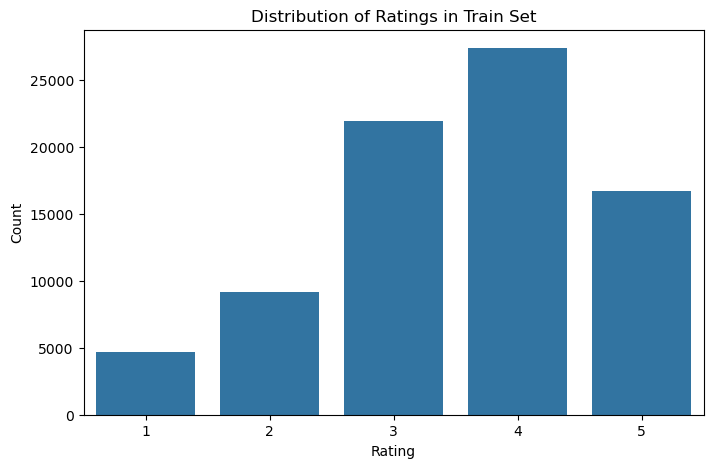

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=train)
plt.title("Distribution of Ratings in Train Set")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


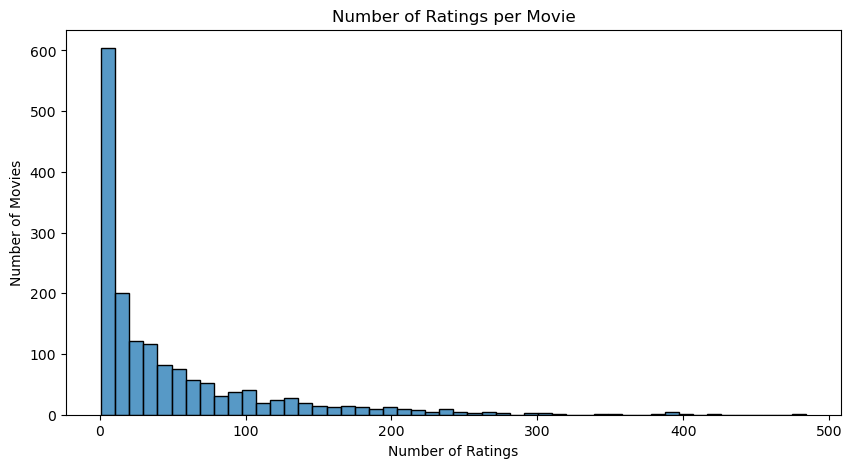

In [34]:
movie_rating_count = train.groupby('movie_id')['rating'].count().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.histplot(movie_rating_count, bins=50, kde=False)
plt.title("Number of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()



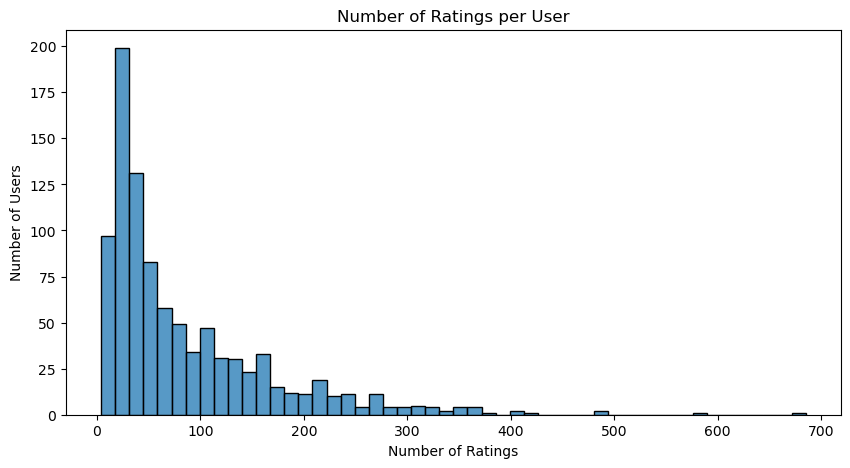

In [35]:
user_rating_count = train.groupby('user_id')['rating'].count()

plt.figure(figsize=(10,5))
sns.histplot(user_rating_count, bins=50, kde=False)
plt.title("Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()


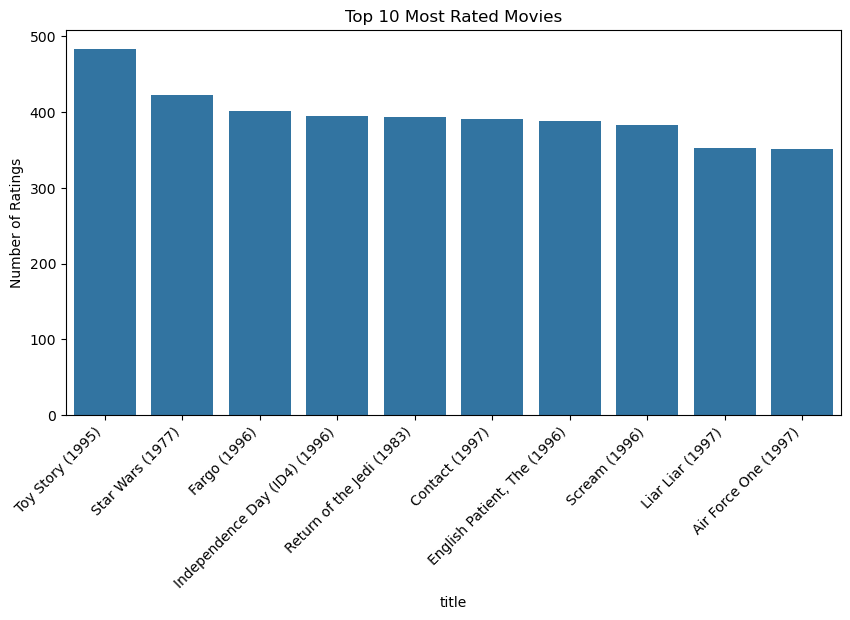

In [36]:
top_movies = movie_rating_count.head(10).index
top_movies_titles = movies[movies['movie_id'].isin(top_movies)]

plt.figure(figsize=(10,5))
sns.barplot(x=top_movies_titles['title'], y=movie_rating_count.head(10).values)
plt.title("Top 10 Most Rated Movies")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Ratings")
plt.show()
